In [10]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [30]:
# 1. define the state.
class BMIClass(TypedDict):

    weight_kg: float
    height_m: float
    bmi: float 
    category: str

In [26]:

def calculate_bmi(state: BMIClass) -> BMIClass:

    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)
    state['bmi'] = bmi

    return state

In [32]:
def label_bmi(state: BMIClass) -> BMIClass:

    bmi = state['bmi']

    if bmi < 18.5 :
        state['category'] = 'Underweight'
    elif 18.5 <= bmi < 25:
        state['category'] = 'Normal'

    elif 25 <=  bmi < 30:
        state['category'] = 'OverWeight'
    else:
        state['category'] = 'Obese'
    
    return state

In [33]:
# Define graph:
graph = StateGraph(BMIClass)

# add nodes to the graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi', label_bmi)

# add edges to the graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_bmi')
graph.add_edge('label_bmi', END)
# compile the graph
workflow= graph.compile()


In [35]:
# execute the graph:

input_state = {'weight_kg': 20,'height_m': 1.72}

final_state = workflow.invoke(input_state)
print(final_state)

{'weight_kg': 20, 'height_m': 1.72, 'bmi': 6.760411032990807, 'category': 'Underweight'}


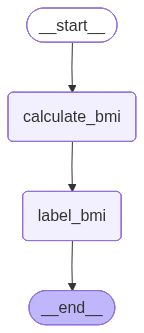

In [36]:
## visualization of graph:
from IPython.display import Image

Image(
    workflow.get_graph().draw_mermaid_png()
)
